# Mutual Information

Mutual information (MI) measures how much knowing one variable reduces uncertainty about another. Unlike covariance and Pearson correlation, it captures **any** statistical dependency — linear or non-linear.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')
print('Shape:', df.shape)

Shape: (891, 15)


## Three Ways to Measure Dependency

| Measure | What it captures | Range | Scale-invariant | Non-linear? |
|---|---|---|---|---|
| **Covariance** | Direction of linear co-movement | (−∞, +∞) | No — unit-dependent | No |
| **Pearson r** | Strength + direction of linear relationship | [−1, +1] | Yes | No |
| **Mutual Information** | Any statistical dependency | [0, +∞) | Yes | **Yes** |

**Covariance → Correlation → Mutual Information** is a progression from the weakest to the most general measure:

- Covariance tells you *direction* but its magnitude is meaningless without knowing the units.
- Pearson r normalises covariance so you can compare pairs — but it is blind to curves, U-shapes, and other non-linear patterns.
- Mutual information makes no assumptions about the functional form — it detects any dependency, including non-linear, threshold, and interaction effects.

**The cost**: MI has no sign (it cannot tell you whether the dependency is positive or negative), and its magnitude is harder to interpret intuitively than r.

## The Information-Theoretic Foundation

Mutual information is defined in terms of **entropy** — the average uncertainty in a variable:

$$H(X) = -\sum_x p(x) \log p(x)$$

MI is the reduction in uncertainty about Y after observing X:

$$I(X; Y) = H(Y) - H(Y \mid X) = H(X) + H(Y) - H(X, Y)$$

| Value | Meaning |
|---|---|
| I(X;Y) = 0 | X and Y are completely independent |
| I(X;Y) > 0 | Knowing X reduces uncertainty about Y |
| I(X;Y) = H(Y) | X perfectly determines Y |

## Where Pearson r Fails but MI Succeeds

Pearson r measures only linear relationships. Non-linear patterns — quadratic, sinusoidal, threshold — produce r ≈ 0 even when X is fully predictive of Y.

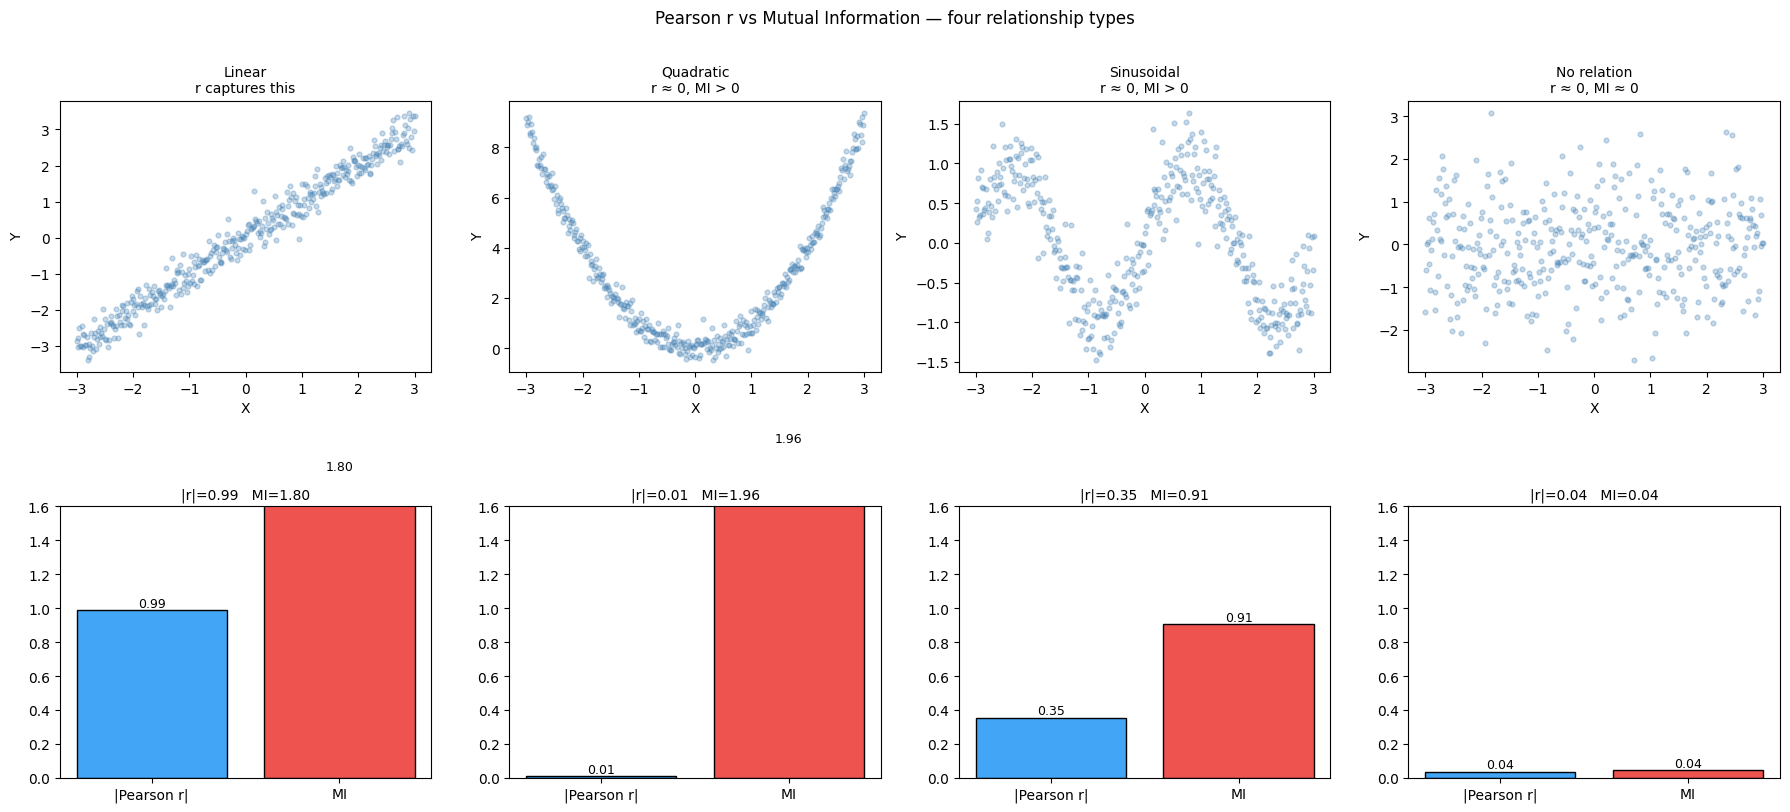

In [2]:
np.random.seed(42)
n = 400
x = np.linspace(-3, 3, n)
noise = np.random.randn(n) * 0.3

scenarios = [
    ('Linear',     x + noise,          'r captures this'),
    ('Quadratic',  x**2 + noise,       'r ≈ 0, MI > 0'),
    ('Sinusoidal', np.sin(2*x) + noise,'r ≈ 0, MI > 0'),
    ('No relation',np.random.randn(n), 'r ≈ 0, MI ≈ 0'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, (label, y, note) in enumerate(scenarios):
    r = np.corrcoef(x, y)[0, 1]
    mi = mutual_info_regression(
        x.reshape(-1, 1), y, random_state=42
    )[0]

    # Scatter
    axes[0, col].scatter(x, y, alpha=0.3, s=12, color='steelblue')
    axes[0, col].set_title(f'{label}\n{note}', fontsize=10)
    axes[0, col].set_xlabel('X')
    axes[0, col].set_ylabel('Y')

    # Bar comparison
    bars = axes[1, col].bar(['|Pearson r|', 'MI'], [abs(r), mi],
                             color=['#42A5F5', '#EF5350'], edgecolor='black')
    axes[1, col].set_ylim(0, 1.6)
    axes[1, col].set_title(f'|r|={abs(r):.2f}   MI={mi:.2f}', fontsize=10)
    for bar in bars:
        h = bar.get_height()
        axes[1, col].text(bar.get_x() + bar.get_width()/2, h + 0.02,
                          f'{h:.2f}', ha='center', fontsize=9)

plt.suptitle('Pearson r vs Mutual Information — four relationship types', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Computing MI with scikit-learn

scikit-learn provides two estimators:

| Function | Use when target is |
|---|---|
| `mutual_info_classif` | Categorical (classification) |
| `mutual_info_regression` | Numerical (regression) |

Both accept a 2D feature matrix `X` and a 1D target `y`, and return one MI score per feature.

Important parameters:
- `discrete_features=True` — set for integer/categorical columns so MI is computed correctly
- `random_state` — MI uses nearest-neighbour estimation; set for reproducibility

In [3]:
# Feature selection: MI of each feature vs the binary target 'survived'
features = ['age', 'fare', 'pclass', 'sibsp', 'parch']
target = 'survived'

df_sub = df[features + [target]].dropna()
X = df_sub[features]
y = df_sub[target]

# pclass, sibsp, parch are discrete integers
discrete_mask = [False, False, True, True, True]

mi_scores = mutual_info_classif(
    X, y,
    discrete_features=discrete_mask,
    random_state=42
)

mi_df = pd.DataFrame({
    'feature': features,
    'MI':      mi_scores,
    'Pearson |r|': [abs(X[f].corr(y)) for f in features]
}).sort_values('MI', ascending=False)

print(mi_df.round(4).to_string(index=False))

feature     MI  Pearson |r|
   fare 0.1305       0.2682
 pclass 0.0663       0.3597
    age 0.0383       0.0772
  parch 0.0208       0.0933
  sibsp 0.0169       0.0174


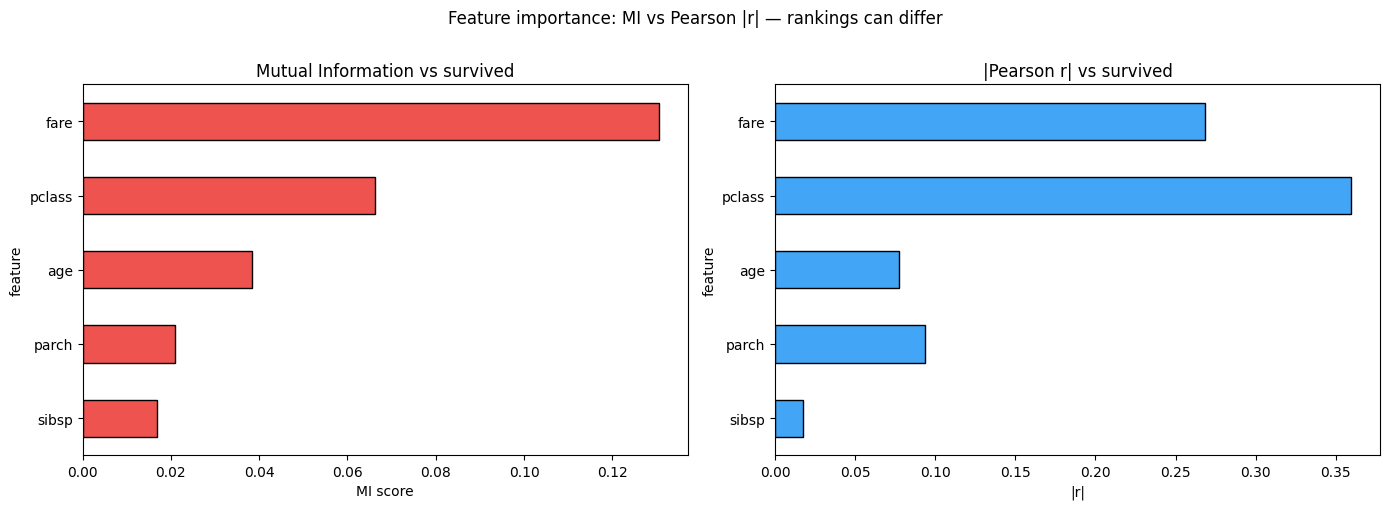

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mi_df.plot(x='feature', y='MI', kind='barh', ax=axes[0],
           color='#EF5350', edgecolor='black', legend=False)
axes[0].set_title('Mutual Information vs survived')
axes[0].set_xlabel('MI score')
axes[0].invert_yaxis()

mi_df.plot(x='feature', y='Pearson |r|', kind='barh', ax=axes[1],
           color='#42A5F5', edgecolor='black', legend=False)
axes[1].set_title('|Pearson r| vs survived')
axes[1].set_xlabel('|r|')
axes[1].invert_yaxis()

plt.suptitle('Feature importance: MI vs Pearson |r| — rankings can differ', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## MI for Feature Selection

Ranking features by MI before modelling is a fast, model-agnostic filter method:

```python
from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector = SelectKBest(score_func=mutual_info_classif, k=3)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()].tolist()
```

Use MI-based selection when:
- You suspect non-linear relationships between features and the target
- You want a quick, interpretable feature ranking before running any model
- Correlation-based selection drops useful non-linear features

Top-3 features by MI: ['age', 'fare', 'pclass']


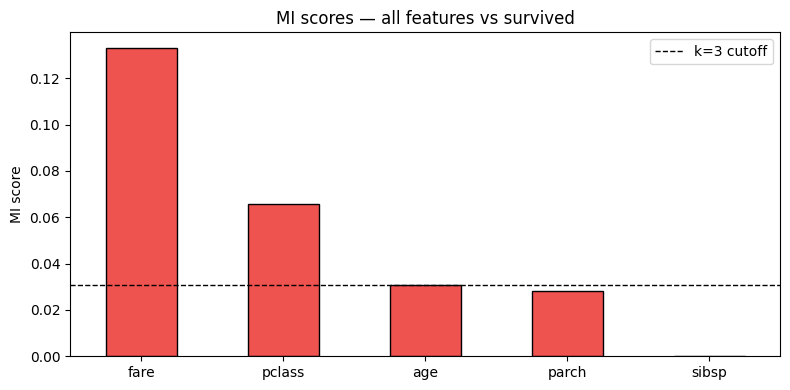

In [5]:
from sklearn.feature_selection import SelectKBest

selector = SelectKBest(score_func=mutual_info_classif, k=3)
selector.fit(X, y)

selected = X.columns[selector.get_support()].tolist()
print(f'Top-3 features by MI: {selected}')

scores = pd.Series(selector.scores_, index=features).sort_values(ascending=False)
scores.plot(kind='bar', color='#EF5350', edgecolor='black', figsize=(8, 4))
plt.title('MI scores — all features vs survived')
plt.ylabel('MI score')
plt.xticks(rotation=0)
plt.axhline(scores.nlargest(3).min(), color='black', linestyle='--',
            linewidth=1, label='k=3 cutoff')
plt.legend()
plt.tight_layout()
plt.show()

## Key Takeaways

| | Covariance | Pearson r | Mutual Information |
|---|---|---|---|
| **Range** | (−∞, +∞) | [−1, +1] | [0, +∞) |
| **Captures linear?** | Yes | Yes | Yes |
| **Captures non-linear?** | No | No | **Yes** |
| **Has sign (direction)?** | Yes | Yes | **No** |
| **Scale-invariant?** | No | Yes | Yes |
| **Interpretable magnitude?** | No | Yes (0.8 = strong) | Harder — relative ranking |
| **sklearn API** | — | `df.corr()` | `mutual_info_classif` / `mutual_info_regression` |

**When to use each:**
- **Correlation** — quick check for linear relationships; heatmap for all pairs at once
- **Mutual information** — when non-linear relationships are plausible, or for model-agnostic feature selection
- **Covariance** — rarely used directly; mainly a building block for correlation and PCA